In [1]:
from sklearn.cluster import DBSCAN, HDBSCAN
from sklearn.preprocessing import StandardScaler
import umap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

C:\Users\Niels de Klerk\PyCharmMiscProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_total = pd.read_pickle('../../all_fluxes_new.pkl')

In [3]:
df_total.columns

Index(['id', 'tile_index', 'ra', 'dec', 'FWHM', 'point_source_probability_mer',
       'weight_size', 'CFIS-U', 'CFIS-U_sigma', 'NIR-Y', 'NIR-Y_sigma',
       'CFIS-R', 'CFIS-R_sigma', 'NIR-J', 'NIR-J_sigma', 'NIR-H',
       'NIR-H_sigma', 'WISHES-Z', 'WISHES-Z_sigma', 'PANSTARRS-I',
       'PANSTARRS-I_sigma', 'WISHES-G', 'WISHES-G_sigma', 'VIS', 'VIS_sigma',
       'DES-Z', 'DES-Z_sigma', 'DES-I', 'DES-I_sigma', 'DES-G', 'DES-G_sigma',
       'DES-R', 'DES-R_sigma', 'label'],
      dtype='str')

In [24]:
galaxy = df_total[df_total['label'] == 0]
stars = df_total[df_total['label'] == 1]

In [25]:
print(len(stars), len(galaxy))

202154 322961


In [8]:
def color(df, filters):
    filter_1, filter_2 = filters
    return -2.5*np.log10(df[filter_1] / df[filter_2])

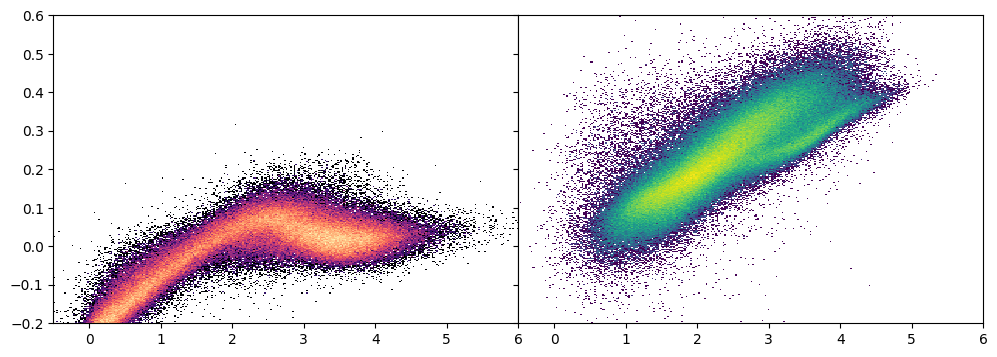

In [27]:
xmin,xmax = -.5, 6
ymin,ymax = -.2, .6
n_bins= 300
x_bins = np.linspace(xmin, xmax, n_bins+1)
y_bins = np.linspace(ymin, ymax, n_bins+1)
bins = (x_bins, y_bins)
x_color = ('DES-G', 'NIR-H')
y_color = ('NIR-J', 'NIR-H')
fig, axes = plt.subplots(1,2, sharey=True, sharex=True, figsize=(12,4), gridspec_kw={'wspace': 0, 'hspace': 0})
H, xedges, yedges = np.histogram2d(
    color(stars, x_color), color(stars, y_color), bins=bins)
axes[0].pcolormesh(
    xedges,
    yedges,
    H.T,
    # origin='lower',
    # extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    shading='auto',
    norm=LogNorm(),
    rasterized=True,
    cmap='magma'
)
H, xedges, yedges = np.histogram2d(
    color(galaxy, x_color), color(galaxy, y_color), bins=bins)
axes[1].pcolormesh(
    xedges,
    yedges,
    H.T,
    # origin='lower',
    # extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    shading='auto',
    norm=LogNorm(),
    rasterized=True,
    cmap='viridis'
)
# plt.title(f'{np.sum(mask)} sources > .7 PSP {np.sum(~mask)} sources < .7 PSP')
# plt.grid()
# plt.xlabel(x_color.replace('_', '-'))
# plt.ylabel(y_color.replace('_', '-'))
# for ax in axes:
#     ax.grid(True)
#     ax.set_xlabel(x_color.replace('_', '-'))
# # plt.xlim(-1.5, 2)
# # plt.ylim(-1, 1)
# axes[0].set_ylabel(y_color.replace('_', '-'))
plt.show()

In [28]:
DES = True
if DES:
    bands = ['DES-G','DES-R','DES-I','DES-Z','VIS','NIR-Y','NIR-J','NIR-H']
else:
    bands = ['CFIS-U','WISHES-G','CFIS-R','PANSTARRS-I','WISHES-Z','VIS','NIR-Y','NIR-J','NIR-H']

for b in bands:
    galaxy[f'{b}_mag'] = -2.5*np.log10(galaxy[b])
if DES:
    galaxy['g_r'] = galaxy['DES-G_mag'] - galaxy['DES-R_mag']
    galaxy['r_i'] = galaxy['DES-R_mag'] - galaxy['DES-I_mag']
    galaxy['i_z'] = galaxy['DES-I_mag'] - galaxy['DES-Z_mag']
    galaxy['z_VIS'] = galaxy['DES-Z_mag'] - galaxy['VIS_mag']
    galaxy['VIS_Y'] = galaxy['VIS_mag'] - galaxy['NIR-Y_mag']
    galaxy['Y_J'] = galaxy['NIR-Y_mag'] - galaxy['NIR-J_mag']
    galaxy['J_H'] = galaxy['NIR-J_mag'] - galaxy['NIR-H_mag']
    galaxy['g_H'] = galaxy['DES-G_mag'] - galaxy['NIR-H_mag']
else:
    galaxy['u_g'] = galaxy['CFIS-U_mag'] - galaxy['WISHES-G_mag']
    galaxy['g_r'] = galaxy['WISHES-G_mag'] - galaxy['CFIS-R_mag']
    galaxy['r_i'] = galaxy['CFIS-R_mag'] - galaxy['PANSTARRS-I_mag']
    galaxy['i_z'] = galaxy['PANSTARRS-I_mag'] - galaxy['WISHES-Z_mag']
    galaxy['z_VIS'] = galaxy['WISHES-Z_mag'] - galaxy['VIS_mag']
    galaxy['VIS_Y'] = galaxy['VIS_mag'] - galaxy['NIR-Y_mag']
    galaxy['Y_J'] = galaxy['NIR-Y_mag'] - galaxy['NIR-J_mag']
    galaxy['J_H'] = galaxy['NIR-J_mag'] - galaxy['NIR-H_mag']
    galaxy['u_H'] = galaxy['CFIS-U_mag'] - galaxy['NIR-H_mag']

In [29]:
plt.show()
if DES:
    features = ['g_r', 'r_i', 'i_z', 'z_VIS', 'VIS_Y', 'Y_J', 'J_H', 'g_H']
else:
    features = ['u_g', 'g_r', 'r_i', 'VIS_Y', 'Y_J', 'u_H', 'J_H']

X = galaxy[features].values

mask = np.isfinite(X).all(axis=1)

X = X[mask]
print(len(X), len(galaxy))

287721 322961


In [30]:
Xn = StandardScaler().fit_transform(X)

In [163]:
idx = np.random.choice(
    Xn.shape[0],
    size=50000,
    replace=False
)

X_subset = Xn[idx]
X_subset = Xn

In [164]:
embedding_2d = umap.UMAP(
    n_neighbors=50,
    min_dist=0.0,
    spread=3.0
).fit_transform(X_subset)

In [178]:
clusterer = HDBSCAN(
    min_cluster_size=10000,
    min_samples=500
)

labels = clusterer.fit_predict(embedding_2d)
print(np.unique(labels, return_counts=True))

C:\Users\Niels de Klerk\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


(array([-1,  0,  1,  2]), array([ 97875,  16458, 153026,  20362]))


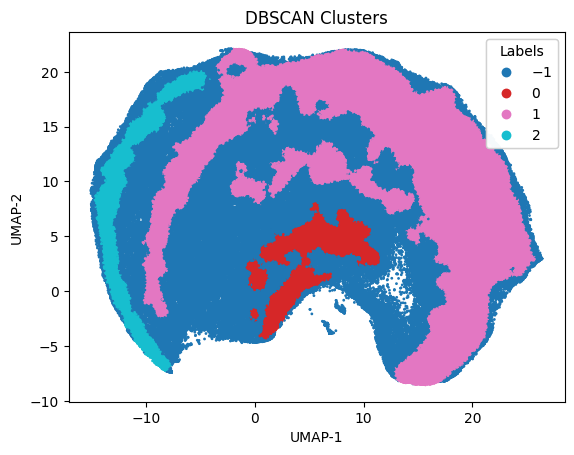

In [179]:
scatter = plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=labels,
    s=1,
    cmap='tab10'
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("DBSCAN Clusters")
# Create legend entries from the scatter plot
legend = plt.legend(
    *scatter.legend_elements(),
    title="Labels"
)

plt.gca().add_artist(legend)

plt.show()

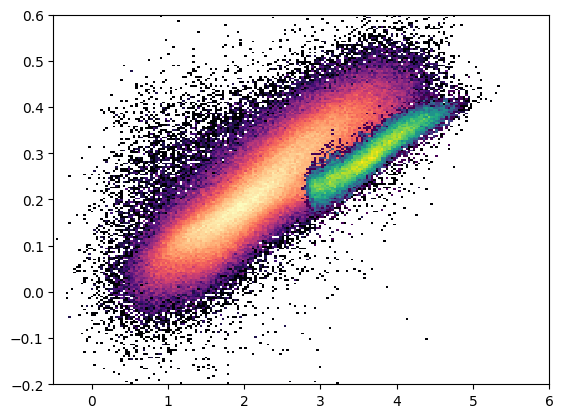

In [185]:
mask = (labels == 2) #| (labels==3)
x_color = -1
y_color = -2
n_bins= 200
x_bins = np.linspace(xmin, xmax, n_bins+1)
y_bins = np.linspace(ymin, ymax, n_bins+1)
bins = (x_bins, y_bins)
H, xedges, yedges = np.histogram2d(
    X[:, x_color][~mask], X[:, y_color][~mask], bins=bins)
plt.pcolormesh(
    xedges,
    yedges,
    H.T,
    # origin='lower',
    # extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    shading='auto',
    norm=LogNorm(),
    rasterized=True,
    cmap='magma'
)
H, xedges, yedges = np.histogram2d(
    X[:, x_color][mask], X[:, y_color][mask], bins=bins)
plt.pcolormesh(
    xedges,
    yedges,
    H.T,
    # origin='lower',
    # extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    shading='auto',
    norm=LogNorm(),
    rasterized=True,
    cmap='viridis'
)
plt.show()

In [192]:
np.save('labels.npy', labels)

In [193]:
labels = np.load('labels.npy')

In [194]:
branch = galaxy[np.isfinite(galaxy[features].values).all(axis=1)][labels == 2]

In [195]:
branch[branch['tile_index']==102018665]

,id,tile_index,ra,dec,FWHM,point_source_probability_mer,weight_size,CFIS-U,CFIS-U_sigma,NIR-Y,...,NIR-J_mag,NIR-H_mag,g_r,r_i,i_z,z_VIS,VIS_Y,Y_J,J_H,g_H
19414036,-574471798511608679,102018665,57.447180,-51.160868,1.370116,0.000000e+00,1.375,NaN,NaN,84712.500895,...,-12.630037,-12.958758,1.611676,0.731324,0.268477,-0.611669,1.084702,0.310169,0.328721,3.723399
19414070,-575955048511603855,102018665,57.595505,-51.160386,1.346131,1.652644e-05,1.345,NaN,NaN,45668.027430,...,-11.921438,-12.146659,1.307541,0.516199,0.314233,-0.560597,0.907802,0.272407,0.225222,2.982807
19414599,-573857570511554304,102018665,57.385757,-51.155430,1.437351,0.000000e+00,1.435,NaN,NaN,111019.461244,...,-12.916984,-13.146851,1.188770,0.607665,0.201692,-0.522171,0.891637,0.303486,0.229867,2.900946
19415080,-575620230511504875,102018665,57.562023,-51.150488,1.473912,2.160951e-03,1.475,NaN,NaN,38042.714393,...,-11.789963,-12.092993,1.671072,0.830776,0.360849,-0.782844,1.167223,0.339284,0.303030,3.889391
19415974,-574935203511422932,102018665,57.493520,-51.142293,1.480020,1.001155e-06,1.485,NaN,NaN,64721.694008,...,-12.386629,-12.648899,1.490723,0.737634,0.245909,-0.602905,1.007818,0.359004,0.262270,3.500453
19416356,-575196537511383465,102018665,57.519654,-51.138347,1.402895,9.527596e-05,1.405,NaN,NaN,35710.688723,...,-11.768354,-12.092820,1.743871,0.739843,0.349088,-0.743221,1.145879,0.386358,0.324466,3.946284
19417902,-574231978511211476,102018665,57.423198,-51.121148,1.481652,3.353900e-03,1.485,NaN,NaN,32776.295956,...,-11.639587,-11.944895,1.617986,0.822853,0.349529,-0.738477,1.107453,0.350687,0.305308,3.815340
19418398,-573935403511156889,102018665,57.393540,-51.115689,1.429663,3.448808e-04,1.425,NaN,NaN,32323.980083,...,-11.592874,-11.954958,1.829000,0.796454,0.278915,-0.722751,1.192445,0.319062,0.362084,4.055208
19418679,-574387795511125024,102018665,57.438780,-51.112502,1.361416,0.000000e+00,1.365,NaN,NaN,71488.134376,...,-12.424488,-12.661108,1.208812,0.551328,0.294800,-0.543694,0.882436,0.288903,0.236620,2.919205
19419968,-574462818510989919,102018665,57.446282,-51.098992,1.349369,2.474209e-04,1.345,NaN,NaN,48044.715321,...,-12.044677,-12.304716,1.552369,0.653034,0.232744,-0.561147,0.967469,0.340563,0.260039,3.445071
